In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# ml
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from scipy.stats.mstats import winsorize
from sklearn.linear_model import Lasso
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LassoCV

bf MICE

In [114]:
# data
file_path = r"/Users/selina/Desktop/365mc_re/0.code/1_preprocessing/c_df_raw.csv" # merge_df
df = pd.read_csv(file_path) # 7046

print(df.columns.tolist())

['ID', 'branch', 'doctor', 'p_date', 'body_code', 'body_name', 'edema', 'sex', 'age', 'height', 'fat_cc', 'bf_weight', 'af_weight', 'bf_size', 'af_size', 'bf_tbw', 'af_tbw', 'bf_protein', 'af_protein', 'bf_mineral', 'af_mineral', 'bf_ffm', 'af_ffm', 'bf_smm', 'af_smm', 'bf_bfm', 'af_bfm', 'bf_whr', 'af_whr', 'Liposuction type']


In [115]:
unique_ids = df['ID'].unique()
print(unique_ids)
print(f"total p, unique: {len(unique_ids)}") # 4947

[360073593 180033405 360016942 ... 350009171 180031961 320005499]
total p, unique: 4947


In [116]:
df # 8064

,ID,branch,doctor,p_date,body_code,body_name,edema,sex,age,height,...,af_mineral,bf_ffm,af_ffm,bf_smm,af_smm,bf_bfm,af_bfm,bf_whr,af_whr,Liposuction type
0,360073593,서울,pingwa,20240129,7,복부,약간의 붓기,F,38,166.0,...,2.98,41.8,39.7,22.2,21.0,24.1,22.1,0.93,0.94,surgery
1,180033405,대전,ssungm,20240125,7,복부,NaN,F,44,163.0,...,2.70,38.6,42.3,21.0,23.1,16.6,16.0,0.93,0.94,surgery
2,360016942,서울,pingwa,20240110,7,복부,NaN,F,44,154.0,...,2.76,38.0,38.5,20.4,20.6,23.6,21.2,0.91,0.87,surgery
3,360073502,서울,pingwa,20240124,6,팔,약간의 붓기,F,42,160.0,...,3.13,41.7,43.8,22.7,24.0,30.3,26.4,0.99,0.95,surgery
4,360073596,서울,pingwa,20240111,12,허벅지,약간의 붓기,F,21,165.0,...,3.46,48.2,46.4,26.4,25.3,34.1,33.5,0.88,0.86,surgery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8059,320005499,부천,md2217,20240110,12,허벅지,NaN,F,36,162.0,...,NaN,47.6,NaN,26.4,NaN,34.9,NaN,1.00,NaN,lams
8060,60022070,영등포,md2217,20240308,12,허벅지,약간의 붓기,F,33,173.0,...,NaN,50.4,NaN,27.6,NaN,49.6,NaN,1.07,NaN,lams
8061,60022070,영등포,md2217,20240308,12,허벅지,약간의 붓기,F,33,173.0,...,NaN,50.4,NaN,27.6,NaN,49.6,NaN,1.07,NaN,lams
8062,60022070,영등포,md2217,20240308,12,허벅지,약간의 붓기,F,33,173.0,...,NaN,50.4,NaN,27.6,NaN,49.6,NaN,1.07,NaN,lams


In [117]:
# BMI: kg/m² = weight / (height in m)^2
df['BMI'] = df['bf_weight'] / ((df['height'] / 100) ** 2)
df['BMI'] = df['BMI'].round(2)
df

,ID,branch,doctor,p_date,body_code,body_name,edema,sex,age,height,...,bf_ffm,af_ffm,bf_smm,af_smm,bf_bfm,af_bfm,bf_whr,af_whr,Liposuction type,BMI
0,360073593,서울,pingwa,20240129,7,복부,약간의 붓기,F,38,166.0,...,41.8,39.7,22.2,21.0,24.1,22.1,0.93,0.94,surgery,23.91
1,180033405,대전,ssungm,20240125,7,복부,NaN,F,44,163.0,...,38.6,42.3,21.0,23.1,16.6,16.0,0.93,0.94,surgery,20.78
2,360016942,서울,pingwa,20240110,7,복부,NaN,F,44,154.0,...,38.0,38.5,20.4,20.6,23.6,21.2,0.91,0.87,surgery,25.97
3,360073502,서울,pingwa,20240124,6,팔,약간의 붓기,F,42,160.0,...,41.7,43.8,22.7,24.0,30.3,26.4,0.99,0.95,surgery,28.12
4,360073596,서울,pingwa,20240111,12,허벅지,약간의 붓기,F,21,165.0,...,48.2,46.4,26.4,25.3,34.1,33.5,0.88,0.86,surgery,30.23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8059,320005499,부천,md2217,20240110,12,허벅지,NaN,F,36,162.0,...,47.6,NaN,26.4,NaN,34.9,NaN,1.00,NaN,lams,31.44
8060,60022070,영등포,md2217,20240308,12,허벅지,약간의 붓기,F,33,173.0,...,50.4,NaN,27.6,NaN,49.6,NaN,1.07,NaN,lams,33.41
8061,60022070,영등포,md2217,20240308,12,허벅지,약간의 붓기,F,33,173.0,...,50.4,NaN,27.6,NaN,49.6,NaN,1.07,NaN,lams,33.41
8062,60022070,영등포,md2217,20240308,12,허벅지,약간의 붓기,F,33,173.0,...,50.4,NaN,27.6,NaN,49.6,NaN,1.07,NaN,lams,33.41


Define ID based on the number of surgeries

In [112]:
# missing (p_date)
missing_count = df['p_date'].isna().sum()
missing_ratio = df['p_date'].isna().mean() * 100

print(f"결측치 개수: {missing_count}")
print(f"결측치 비율: {missing_ratio:.2f}%")

결측치 개수: 0
결측치 비율: 0.00%


In [113]:
df2 = df[df['p_date'].notna()].copy()
print(f"결측치 제거 후 남은 행 수: {len(df2)}") # 8064

결측치 제거 후 남은 행 수: 8064


rename_dict = {
    'psentry': 'ID',
    '지점명': 'branch',  # label encoding 
    'DOCTOR_NAME': 'doctor',  # label encoding
    'p_date': 'p_date', # non included
    'body_code': 'body_code', # num 9 > 7
    'body_name': 'body_name', # rename
    '부종(현재 붓기가 있나요?)': 'edema',  # ordinary encoding > MICE
    'sex': 'sex', # label encoding
    'age': 'age', # outlier check
    '키': 'height', # outlier check
    '추출량(Bottle)': 'fat_cc', # outlier check
    '인바디체중': 'bf_weight', # outlier check
    '전사이즈': 'bf_size', # outlier check
    '추출량(Bottle)': 'fat_cc', # outlier check
    '체수분': 'bf_tbw', # outlier check
    '단백질': 'bf_protein', # outlier check
    '무기질': 'bf_mineral', # outlier check 
    '제지방량': 'bf_ffm', # outlier check
    '골격근량': 'bf_smm', # outlier check
    '체지방량': 'bf_bfm', # outlier check
    '복부지방률': 'bf_whr', # outlier check
}

In [81]:
# body
df2.groupby(['body_code', 'body_name']).size().reset_index(name='count')

,body_code,body_name,count
0,0,공통,8
1,4,등,344
2,6,팔,3551
3,7,복부,1948
4,8,힙,25
5,9,힙업,104
6,10,러브핸들,566
7,12,허벅지,1419
8,13,종아리,99


In [82]:
# 1. '공통' 제거
df3 = df2[df2['body_name'] != '공통'].copy() # -8
# 2. new_mapping
new_code_map = {
    7: 1,  # 복부 → Abdomen
    6: 2,  # 팔 → Arms
    4: 3,  # 등 → Backs
    8: 4, 9: 4,  # 힙, 힙업 → Buttocks
    13: 5,  # 종아리 → Calves
    10: 6,  # 러브핸들 → Flanks
    12: 7   # 허벅지 → Thighs
}
new_name_map = {
    1: 'Abdomen',
    2: 'Arms',
    3: 'Backs',
    4: 'Buttocks',
    5: 'Calves',
    6: 'Flanks',
    7: 'Thighs'
}

df3['body_code'] = df3['body_code'].map(new_code_map)
df3['body_name'] = df3['body_code'].map(new_name_map)
print(df3[['body_code', 'body_name']].drop_duplicates())  # 8056

      body_code body_name
0             1   Abdomen
3             2      Arms
4             7    Thighs
14            5    Calves
1027          6    Flanks
1031          3     Backs
1115          4  Buttocks


In [83]:
# body
df3.groupby(['body_code', 'body_name']).size().reset_index(name='count')

,body_code,body_name,count
0,1,Abdomen,1948
1,2,Arms,3551
2,3,Backs,344
3,4,Buttocks,129
4,5,Calves,99
5,6,Flanks,566
6,7,Thighs,1419


In [84]:
# sex and edema (bf MICE)
print(df3['edema'].value_counts(dropna=False)) # 마지막에 MICE 예정
print(df3['sex'].value_counts(dropna=False))

edema
약간의 붓기             5138
NaN                2038
생활 불편이 있는 심한 붓기     445
없음                  435
Name: count, dtype: int64
sex
F    7855
M     198
E       3
Name: count, dtype: int64


In [85]:
# sex: encoding 
df4 = df3[df3['sex'].isin(['F', 'M'])].copy()
sex_map = {'M': 1, 'F': 2}
df4['sex'] = df4['sex'].map(sex_map)

# edema: ordinary encoding (label encoding X)
edema_map = {
    '없음': 1,
    '약간의 붓기': 2,
    '생활 불편이 있는 심한 붓기': 3,
    np.nan: 1
}
df4['edema'] = df4['edema'].map(edema_map).fillna(0).astype(int)

print(df4['sex'].value_counts())
print(df4['edema'].value_counts())

sex
2    7855
1     198
Name: count, dtype: int64
edema
2    5138
1    2470
3     445
Name: count, dtype: int64


In [86]:
df4

,ID,branch,doctor,p_date,body_code,body_name,edema,sex,age,height,...,af_mineral,bf_ffm,af_ffm,bf_smm,af_smm,bf_bfm,af_bfm,bf_whr,af_whr,Liposuction type
0,360073593,서울,pingwa,20240129,1,Abdomen,2,2,38,166.0,...,2.98,41.8,39.7,22.2,21.0,24.1,22.1,0.93,0.94,surgery
1,180033405,대전,ssungm,20240125,1,Abdomen,1,2,44,163.0,...,2.70,38.6,42.3,21.0,23.1,16.6,16.0,0.93,0.94,surgery
2,360016942,서울,pingwa,20240110,1,Abdomen,1,2,44,154.0,...,2.76,38.0,38.5,20.4,20.6,23.6,21.2,0.91,0.87,surgery
3,360073502,서울,pingwa,20240124,2,Arms,2,2,42,160.0,...,3.13,41.7,43.8,22.7,24.0,30.3,26.4,0.99,0.95,surgery
4,360073596,서울,pingwa,20240111,7,Thighs,2,2,21,165.0,...,3.46,48.2,46.4,26.4,25.3,34.1,33.5,0.88,0.86,surgery
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8059,320005499,부천,md2217,20240110,7,Thighs,1,2,36,162.0,...,NaN,47.6,NaN,26.4,NaN,34.9,NaN,1.00,NaN,lams
8060,60022070,영등포,md2217,20240308,7,Thighs,2,2,33,173.0,...,NaN,50.4,NaN,27.6,NaN,49.6,NaN,1.07,NaN,lams
8061,60022070,영등포,md2217,20240308,7,Thighs,2,2,33,173.0,...,NaN,50.4,NaN,27.6,NaN,49.6,NaN,1.07,NaN,lams
8062,60022070,영등포,md2217,20240308,7,Thighs,2,2,33,173.0,...,NaN,50.4,NaN,27.6,NaN,49.6,NaN,1.07,NaN,lams


In [88]:
# label encoding
from sklearn.preprocessing import LabelEncoder
df5 = df4.copy()
label_cols = {
    'branch': 'branch_',
    'doctor': 'doctor_',
    'Liposuction type': 'Liposuction_type_'
}
for col, new_col in label_cols.items():
    le = LabelEncoder()
    df5[new_col] = le.fit_transform(df5[col].astype(str)) 
    
print(df5[['branch', 'branch_']].drop_duplicates().sort_values('branch_'))
print(df5[['doctor', 'doctor_']].drop_duplicates().sort_values('doctor_')) # brach:20, doctor:38
print(df5[['Liposuction type', 'Liposuction_type_']].drop_duplicates().sort_values('Liposuction_type_')) # lams/surgical:1

     branch  branch_
1055   강남본점        0
1792     구리        1
1042     노원        2
10       대구        3
1        대전        4
5        부산        5
1083     부천        6
1021     분당        7
0        서울        8
1078   성신여대        9
1029     수원       10
1115     신촌       11
1022   안양평촌       12
1045    영등포       13
21       인천       14
1032     일산       15
1050     천안       16
1048     천호       17
1054     청주       18
1096    해운대       19
      doctor  doctor_
3492  04kjh1        0
1042   04ldk        1
2156   04lgh        2
96     04lsy        3
5       21sc        4
240    34ajh        5
4006    34hs        6
198   34k122        7
131   34skim        8
51      34sw        9
1264    35hz       10
99    35kmhh       11
802   36ssjw       12
1063   52eyp       13
1055   52nat       14
276   JJM365       15
1459    buty       16
1894     ckh       17
1847    drhj       18
1106  hws202       19
1020  jj8181       20
1792  jrang1       21
618     jwju       22
615     kg35       23
40     kh

In [89]:
df6 = df5.rename(columns={
    'sex': 'Sex',  
    'age': 'Age',
    'height': 'Height',
    'bf_weight': 'Weight',    
    'bf_size': 'Size',
    'bf_whr': 'WHR',
    'BMI': 'BMI',
    'Liposuction_type_': 'Liposuction type',   
    'body_code': 'Liposuction site',   
    'fat_cc': 'Fat volume',
    'edema': 'Edema', 
    'bf_protein': 'Body protein',
    'bf_mineral': 'Body mineral',
    'bf_tbw': 'TBW',
    'bf_ffm': 'FFM',
    'bf_smm': 'SMM',
    'bf_bfm': 'BFM'
})

In [90]:
final_365 = df6.copy()
final_365.to_csv('final_365.csv', index=False, encoding='utf-8-sig') # final_365

Data load

In [91]:
final_365 = pd.read_csv('final_365.csv')
final_365

,ID,branch,doctor,p_date,Liposuction site,body_name,Edema,Sex,Age,Height,...,SMM,af_smm,BFM,af_bfm,WHR,af_whr,Liposuction type,branch_,doctor_,Liposuction type.1
0,360073593,서울,pingwa,20240129,1,Abdomen,2,2,38,166.0,...,22.2,21.0,24.1,22.1,0.93,0.94,surgery,8,32,1
1,180033405,대전,ssungm,20240125,1,Abdomen,1,2,44,163.0,...,21.0,23.1,16.6,16.0,0.93,0.94,surgery,4,36,1
2,360016942,서울,pingwa,20240110,1,Abdomen,1,2,44,154.0,...,20.4,20.6,23.6,21.2,0.91,0.87,surgery,8,32,1
3,360073502,서울,pingwa,20240124,2,Arms,2,2,42,160.0,...,22.7,24.0,30.3,26.4,0.99,0.95,surgery,8,32,1
4,360073596,서울,pingwa,20240111,7,Thighs,2,2,21,165.0,...,26.4,25.3,34.1,33.5,0.88,0.86,surgery,8,32,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8048,320005499,부천,md2217,20240110,7,Thighs,1,2,36,162.0,...,26.4,NaN,34.9,NaN,1.00,NaN,lams,6,28,0
8049,60022070,영등포,md2217,20240308,7,Thighs,2,2,33,173.0,...,27.6,NaN,49.6,NaN,1.07,NaN,lams,13,28,0
8050,60022070,영등포,md2217,20240308,7,Thighs,2,2,33,173.0,...,27.6,NaN,49.6,NaN,1.07,NaN,lams,13,28,0
8051,60022070,영등포,md2217,20240308,7,Thighs,2,2,33,173.0,...,27.6,NaN,49.6,NaN,1.07,NaN,lams,13,28,0


In [92]:
final_365.drop(columns=['branch','doctor','p_date','body_name','af_tbw','af_protein','af_mineral','af_ffm','af_smm','af_bfm','af_whr', 'Liposuction type'], inplace=True)

In [93]:
missing_mask = final_365[['af_weight', 'af_size']].isnull().any(axis=1)
print('결측 행 수:', missing_mask.sum())   #249
final_365_ = final_365.dropna(subset=['af_weight', 'af_size'])
final_365_   # 7084

결측 행 수: 249


,ID,Liposuction site,Edema,Sex,Age,Height,Fat volume,Weight,af_weight,Size,...,TBW,Body protein,Body mineral,FFM,SMM,BFM,WHR,branch_,doctor_,Liposuction type.1
0,360073593,1,2,2,38,166.0,600.0,65.9,61.8,94.5,...,30.7,8.0,3.10,41.8,22.2,24.1,0.93,8,32,1
1,180033405,1,1,2,44,163.0,1000.0,55.2,58.3,84.0,...,28.3,7.6,2.66,38.6,21.0,16.6,0.93,4,36,1
2,360016942,1,1,2,44,154.0,750.0,61.6,59.7,89.0,...,27.9,7.4,2.65,38.0,20.4,23.6,0.91,8,32,1
3,360073502,2,2,2,42,160.0,1300.0,72.0,70.2,34.0,...,30.5,8.2,3.00,41.7,22.7,30.3,0.99,8,32,1
4,360073596,7,2,2,21,165.0,2100.0,82.3,79.9,71.5,...,35.2,9.4,3.57,48.2,26.4,34.1,0.88,8,32,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7853,350011246,7,2,2,29,163.0,1200.0,56.5,54.4,57.0,...,29.0,7.6,2.88,39.5,21.3,17.0,0.81,3,20,0
7859,520006104,6,1,2,26,157.0,200.0,55.2,55.1,80.0,...,25.1,6.7,2.51,34.3,18.1,20.9,0.89,0,19,0
7864,520006104,1,1,2,26,157.0,350.0,55.2,55.1,80.0,...,25.1,6.7,2.51,34.3,18.1,20.9,0.89,0,19,0
7865,210043890,3,2,2,26,161.0,900.0,72.3,64.4,90.0,...,29.9,8.0,2.99,40.9,22.1,31.4,0.89,5,18,0


In [94]:
final_365_ = final_365_.copy()

final_365_.drop(columns=['branch_', 'doctor_'], inplace=True)
final_365_.rename(columns={'Liposuction type.1': 'Liposuction type'}, inplace=True)
final_365_

,ID,Liposuction site,Edema,Sex,Age,Height,Fat volume,Weight,af_weight,Size,af_size,TBW,Body protein,Body mineral,FFM,SMM,BFM,WHR,Liposuction type
0,360073593,1,2,2,38,166.0,600.0,65.9,61.8,94.5,77.0,30.7,8.0,3.10,41.8,22.2,24.1,0.93,1
1,180033405,1,1,2,44,163.0,1000.0,55.2,58.3,84.0,74.0,28.3,7.6,2.66,38.6,21.0,16.6,0.93,1
2,360016942,1,1,2,44,154.0,750.0,61.6,59.7,89.0,80.0,27.9,7.4,2.65,38.0,20.4,23.6,0.91,1
3,360073502,2,2,2,42,160.0,1300.0,72.0,70.2,34.0,29.5,30.5,8.2,3.00,41.7,22.7,30.3,0.99,1
4,360073596,7,2,2,21,165.0,2100.0,82.3,79.9,71.5,67.4,35.2,9.4,3.57,48.2,26.4,34.1,0.88,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7853,350011246,7,2,2,29,163.0,1200.0,56.5,54.4,57.0,55.0,29.0,7.6,2.88,39.5,21.3,17.0,0.81,0
7859,520006104,6,1,2,26,157.0,200.0,55.2,55.1,80.0,77.7,25.1,6.7,2.51,34.3,18.1,20.9,0.89,0
7864,520006104,1,1,2,26,157.0,350.0,55.2,55.1,80.0,77.8,25.1,6.7,2.51,34.3,18.1,20.9,0.89,0
7865,210043890,3,2,2,26,161.0,900.0,72.3,64.4,90.0,86.0,29.9,8.0,2.99,40.9,22.1,31.4,0.89,0


In [95]:
# 0512 revision
final_365_ = final_365_.drop(columns=['Fat volume', 'Edema']) # pre-surgery

In [96]:
# imputation은 data leakage 이유로, split 하고 나서 진행해야함.

In [97]:
index=final_365_['ID']
label = final_365_[['af_weight', 'af_size']]

label_n = ['ID','af_weight','af_size']
data = final_365_.drop(label_n, axis=1) 

In [98]:
index

0       360073593
1       180033405
2       360016942
3       360073502
4       360073596
          ...    
7853    350011246
7859    520006104
7864    520006104
7865    210043890
7866    210043890
Name: ID, Length: 7804, dtype: int64

In [99]:
label

,af_weight,af_size
0,61.8,77.0
1,58.3,74.0
2,59.7,80.0
3,70.2,29.5
4,79.9,67.4
...,...,...
7853,54.4,55.0
7859,55.1,77.7
7864,55.1,77.8
7865,64.4,86.0


In [100]:
data

,Liposuction site,Sex,Age,Height,Weight,Size,TBW,Body protein,Body mineral,FFM,SMM,BFM,WHR,Liposuction type
0,1,2,38,166.0,65.9,94.5,30.7,8.0,3.10,41.8,22.2,24.1,0.93,1
1,1,2,44,163.0,55.2,84.0,28.3,7.6,2.66,38.6,21.0,16.6,0.93,1
2,1,2,44,154.0,61.6,89.0,27.9,7.4,2.65,38.0,20.4,23.6,0.91,1
3,2,2,42,160.0,72.0,34.0,30.5,8.2,3.00,41.7,22.7,30.3,0.99,1
4,7,2,21,165.0,82.3,71.5,35.2,9.4,3.57,48.2,26.4,34.1,0.88,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7853,7,2,29,163.0,56.5,57.0,29.0,7.6,2.88,39.5,21.3,17.0,0.81,0
7859,6,2,26,157.0,55.2,80.0,25.1,6.7,2.51,34.3,18.1,20.9,0.89,0
7864,1,2,26,157.0,55.2,80.0,25.1,6.7,2.51,34.3,18.1,20.9,0.89,0
7865,3,2,26,161.0,72.3,90.0,29.9,8.0,2.99,40.9,22.1,31.4,0.89,0


In [68]:
# imputation은 data leakage 이유로, split 하고 나서 진행해야함.

In [101]:
# data split
train_x_, test_x_, train_y, test_y = train_test_split(data, label, test_size=0.3, random_state=1)  # test_size default 0.25
# train_x_, test_x_, train_y_, test_y_ = train_test_split(data, label, test_size = 0.2, stratify = label, random_state = 1) only for categorical

In [103]:
train_x_

,Liposuction site,Sex,Age,Height,Weight,Size,TBW,Body protein,Body mineral,FFM,SMM,BFM,WHR,Liposuction type
7680,2,2,31,163.0,63.4,33.9,29.6,7.9,2.99,40.5,21.9,22.9,0.83,0
2866,7,2,26,170.0,60.3,61.0,32.0,8.4,3.22,43.6,23.5,16.7,0.81,0
6443,7,2,33,159.0,51.1,57.0,27.0,7.3,2.54,36.8,19.7,14.3,0.78,0
6856,1,2,50,160.0,52.8,86.2,25.6,6.7,2.52,34.8,18.2,18.0,0.88,0
5414,1,2,68,153.0,57.0,86.0,27.9,7.4,2.66,38.0,20.5,19.0,0.92,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,1,2,41,170.0,64.8,85.0,31.6,8.5,3.11,43.2,23.5,21.6,0.88,1
5238,1,2,42,165.0,57.6,79.5,28.2,7.5,2.76,38.5,20.6,19.1,0.89,0
4026,7,2,38,155.0,42.6,48.7,25.5,7.0,2.32,34.8,18.9,7.8,0.77,0
236,2,2,37,164.0,59.8,32.0,32.5,8.9,33.00,44.4,24.6,15.4,0.84,1


In [104]:
test_x_

,Liposuction site,Sex,Age,Height,Weight,Size,TBW,Body protein,Body mineral,FFM,SMM,BFM,WHR,Liposuction type
424,2,2,28,152.0,50.1,27.5,23.7,6.3,2.28,32.3,17.1,17.8,0.90,1
7004,6,2,52,162.0,56.8,75.0,30.9,8.2,2.91,42.0,22.6,14.8,0.89,0
1600,1,2,42,165.0,NaN,70.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2827,2,2,34,158.0,57.4,30.5,26.7,7.2,2.64,36.5,19.5,20.9,0.82,0
5965,1,2,31,158.0,60.9,83.0,30.0,8.1,2.90,41.0,22.3,19.9,0.87,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,1,2,41,158.0,67.4,94.0,29.2,7.9,2.68,39.8,21.7,27.6,0.95,1
2074,7,2,35,167.0,67.4,61.0,33.0,8.7,3.23,44.9,24.3,22.5,0.88,0
3741,2,2,34,156.0,60.2,33.5,27.6,7.4,2.65,37.6,20.3,22.6,0.87,0
3749,2,2,28,162.0,71.5,37.5,28.3,7.4,2.76,38.5,20.5,33.0,0.92,0


Imputation + winsorization

In [105]:
# missing rate
# max: 30%; MICE
missing_rate = train_x_.isnull().mean() * 100
missing_rate = missing_rate.sort_values(ascending=False)
print(missing_rate) 

Weight              0.512633
TBW                 0.512633
Body protein        0.512633
Body mineral        0.512633
FFM                 0.512633
SMM                 0.512633
BFM                 0.512633
WHR                 0.512633
Height              0.201391
Liposuction site    0.000000
Sex                 0.000000
Age                 0.000000
Size                0.000000
Liposuction type    0.000000
dtype: float64


In [106]:
# continuous variables with missing values (train_x_)
cols_with_na = [col for col in train_x_.columns if train_x_[col].isna().sum() > 0]

# Imputer (MICE)
imp = IterativeImputer(max_iter=50, random_state=0)  # if 10, warning
train_x_imputed = train_x_.copy()
test_x_imputed = test_x_.copy()

train_x_imputed[cols_with_na] = imp.fit_transform(train_x_[cols_with_na])
test_x_imputed[cols_with_na] = imp.transform(test_x_[cols_with_na])

In [107]:
cols_w = ['Body protein', 'WHR', 'SMM', 'TBW', 'Weight', 'BFM', 'Body mineral', 'FFM', 'Height', 'Age', 'Size', 'BMI']

winsor_check = []
for col in cols_w:
    q01 = train_x_imputed[col].quantile(0.01)
    q99 = train_x_imputed[col].quantile(0.99)
    lower_outliers = (train_x_imputed[col] < q01).sum()
    upper_outliers = (train_x_imputed[col] > q99).sum()
    total_outliers = lower_outliers + upper_outliers

    winsor_check.append({
        'column': col,
        'q01': q01,
        'q99': q99,
        'lower_outliers': lower_outliers,
        'upper_outliers': upper_outliers,
        'total_outliers': total_outliers
    })

winsor_df = pd.DataFrame(winsor_check)

# select cols
apply_cols = winsor_df[winsor_df['total_outliers'] > 10]['column'].tolist()

# winsorization
for col in apply_cols:
    q01 = train_x_imputed[col].quantile(0.01)
    q99 = train_x_imputed[col].quantile(0.99)
    train_x_imputed[col] = train_x_imputed[col].clip(q01, q99)
    test_x_imputed[col] = test_x_imputed[col].clip(q01, q99)

KeyError: 'BMI'

In [33]:
print("Winsorization cols:")
print(apply_cols)

Winsorization cols:
['Body protein', 'WHR', 'SMM', 'TBW', 'Weight', 'BFM', 'Body mineral', 'FFM', 'Height', 'Age', 'Size', 'BMI']


In [34]:
# standardscaler
cols = ['Body protein', 'WHR', 'SMM', 'TBW', 'Weight', 'BFM', 'Body mineral', 'FFM', 'Height', 'Age', 'Size', 'BMI']

train_x = train_x_imputed.copy()
test_x = test_x_imputed.copy()

scaler = StandardScaler()
scaler.fit(train_x[cols]) # only for train

train_x[cols] = scaler.transform(train_x[cols])
test_x[cols] = scaler.transform(test_x[cols])

In [35]:
train_x

,Liposuction site,Sex,Age,Height,Weight,Size,TBW,Body protein,Body mineral,FFM,SMM,BFM,WHR,BMI,Liposuction type
7680,2,2,-0.498445,0.206241,0.032149,-0.931736,-0.130956,-0.144325,-0.258230,-0.111385,-0.125476,0.127280,-0.916407,-0.033660,0
2866,7,2,-1.080675,1.506007,-0.236695,0.116329,0.447466,0.297448,-0.227214,0.436386,0.343827,-0.672705,-1.241142,-0.806471,0
6443,7,2,-0.265553,-0.536482,-1.034553,-0.038367,-0.757580,-0.674453,-0.318912,-0.765177,-0.770768,-0.982377,-1.728245,-0.977058,0
6856,1,2,1.714028,-0.350801,-0.887122,1.090914,-1.094993,-1.204580,-0.321609,-1.118578,-1.210739,-0.504967,-0.104569,-0.871087,0
5414,1,2,2.878488,-1.650567,-0.522883,1.083180,-0.540672,-0.586098,-0.302730,-0.553137,-0.536116,-0.375937,0.544901,0.092988,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
910,1,2,0.666015,1.506007,0.153562,1.044506,0.351063,0.385802,-0.242048,0.365706,0.343827,-0.040459,-0.104569,-0.405850,1
5238,1,2,0.782461,0.577603,-0.470849,0.831799,-0.468369,-0.497744,-0.289245,-0.464786,-0.506785,-0.363034,0.057798,-0.731516,0
4026,7,2,0.316677,-1.279206,-1.497571,-0.359361,-1.119094,-0.939517,-0.348578,-1.118578,-1.005419,-1.472691,-1.890612,-1.458811,0
236,2,2,0.200231,0.391922,-0.280057,-1.005217,0.567971,0.739220,3.788595,0.577747,0.666473,-0.840444,-0.754039,-0.454958,1


In [38]:
desired_order = [
    'Sex', 'Age', 'Height', 'Weight', 'Size', 'BMI', 'WHR', 
    'Liposuction type', 'Liposuction site','Body protein',
    'Body mineral', 'TBW', 'FFM', 'SMM', 'BFM'
]

for df in [train_x, test_x]:
    df = df[[col for col in desired_order if col in df.columns]]
df

,Sex,Age,Height,Weight,Size,BMI,WHR,Liposuction type,Liposuction site,Body protein,Body mineral,TBW,FFM,SMM,BFM
424,2,-0.847783,-1.836248,-1.121276,-1.179250,-0.597114,0.220166,1,2,-1.557999,-0.353972,-1.552911,-1.560330,-1.533385,-0.530772
7004,2,1.946920,0.020560,-0.540228,0.657766,-0.607452,0.057798,0,6,0.120738,-0.269017,0.182356,0.153665,0.079844,-0.917862
1600,2,0.782461,0.577603,0.008775,0.479865,-0.220699,0.079728,0,1,-0.011149,-0.015194,0.002433,0.006534,-0.011367,0.006369
2827,2,-0.149107,-0.722163,-0.488193,-1.063228,-0.258524,-1.078774,0,2,-0.762807,-0.305427,-0.829883,-0.818188,-0.829430,-0.130780
5965,2,-0.498445,-0.722163,-0.184661,0.967158,0.105912,-0.266937,0,1,0.032384,-0.270366,-0.034552,-0.023035,-0.008150,-0.259810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,2,0.666015,-0.722163,0.379043,1.392572,0.777921,1.032004,1,1,-0.144325,-0.300033,-0.227360,-0.235076,-0.184139,0.733720
2074,2,-0.032661,0.948964,0.379043,0.116329,0.046465,-0.104569,0,7,0.562511,-0.225866,0.688476,0.666097,0.578478,0.075668
3741,2,-0.149107,-1.093525,-0.245367,-0.947206,0.193790,-0.266937,0,2,-0.586098,-0.304078,-0.612975,-0.623817,-0.594779,0.088571
3749,2,-0.847783,0.020560,0.734611,-0.792510,0.839953,0.544901,0,2,-0.586098,-0.289245,-0.444268,-0.464786,-0.536116,1.430482


Visulaization

<Figure size 640x480 with 0 Axes>

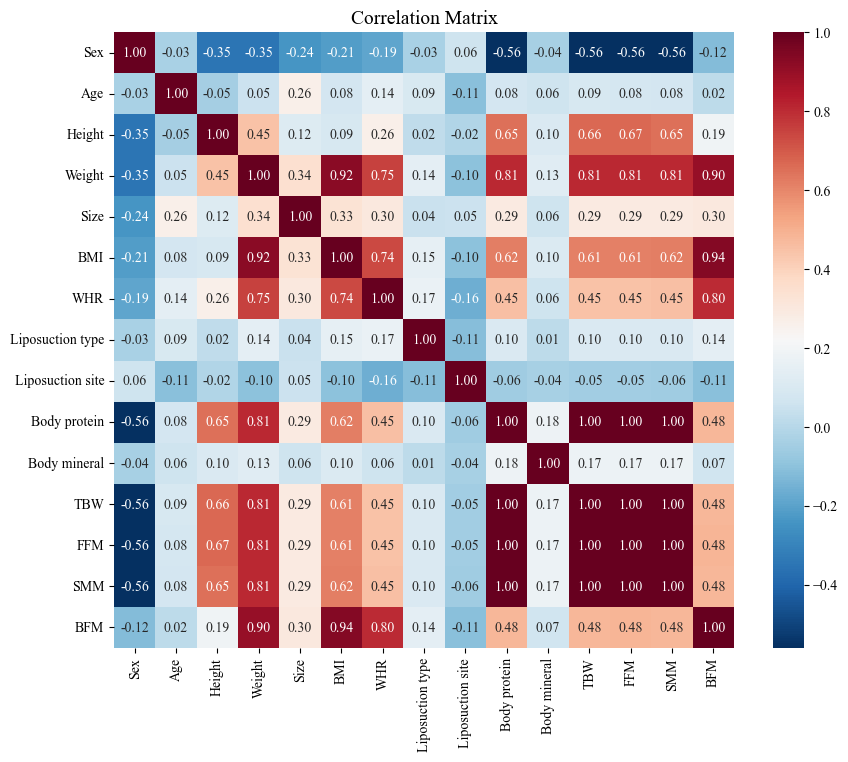

In [39]:
# train_x: feature
cols = [col for col in desired_order if col in train_x.columns]
corr = train_x[cols].corr()

plt.savefig('correlation_matrix.png', dpi=600, bbox_inches='tight')
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdBu_r')
plt.title('Correlation Matrix', fontsize=14)
plt.savefig('correlation_matrix.png', dpi=600, bbox_inches='tight')
plt.show()

Feature selection

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.670e+03, tolerance: 3.568e+02
  model = cd_fast.enet_coordinate_descent(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.850e+03, tolerance: 7.055e+01
  model = cd_fast.enet_coordinate_descent(


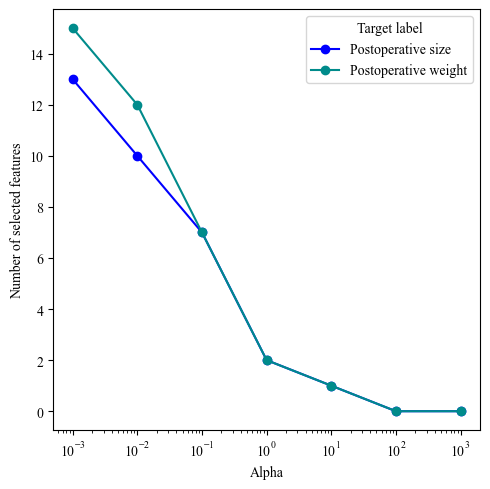

In [40]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]  # sckit-learn: lasso's alpha =lamda
targets = ['af_size', 'af_weight']
results = {}

for target in targets:
    non_zero_counts = []
    for a in alphas:
        model = Lasso(alpha=a)
        model.fit(train_x, train_y[target])
        non_zero_counts.append(sum(model.coef_ != 0))
    results[target] = non_zero_counts

# figure
label_map = {
    'af_size': 'Postoperative size',
    'af_weight': 'Postoperative weight'
}
color_map = {
    'af_size': 'blue',
    'af_weight': 'darkcyan'
}

plt.figure(figsize=(5, 5))
for target in targets:
    plt.plot(
        alphas,
        results[target],
        marker='o',
        label=label_map[target],  
        color=color_map[target]      
    )

plt.xscale('log')
plt.xlabel("Alpha")
plt.ylabel("Number of selected features")
plt.legend(title="Target label", frameon=True, loc='best')
plt.grid(False)                     
plt.tight_layout()
plt.savefig('feature_selection(L1).png', dpi=600, bbox_inches='tight')
plt.show()

In [41]:
# feature selection (included)
alphas = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
results = []

for target in ['af_size', 'af_weight']:
    model = LassoCV(alphas=alphas, cv=5, random_state=42)
    model.fit(train_x, train_y[target])
    
    selected_mask = model.coef_ != 0
    selected = pd.DataFrame({
        'Feature': train_x.columns,
        'Coefficient': model.coef_,
        'Target': target
    })
    selected = selected[selected_mask]
    selected['alpha'] = model.alpha_
    
    results.append(selected)

final_selected = pd.concat(results, ignore_index=True)
final_selected = final_selected.sort_values(by=['Target', 'Coefficient'], ascending=[True, False])
final_selected

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.935e+02, tolerance: 2.836e+02
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.931e+02, tolerance: 2.876e+02
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the numb

,Feature,Coefficient,Target,alpha
5,Size,25.431846,af_size,0.001
9,BFM,3.975540,af_size,0.001
6,TBW,2.600582,af_size,0.001
7,Body protein,0.538213,af_size,0.001
1,Sex,0.470705,af_size,0.001
2,Age,0.142132,af_size,0.001
0,Liposuction site,0.128020,af_size,0.001
8,Body mineral,0.090720,af_size,0.001
10,WHR,-0.078588,af_size,0.001
3,Height,-0.704166,af_size,0.001


In [42]:
# feature selection (excluded)
excluded_results = []

for target in ['af_size', 'af_weight']:
    model = LassoCV(alphas=alphas, cv=5, random_state=42)
    model.fit(train_x, train_y[target])
    
    excluded_mask = model.coef_ == 0
    excluded = pd.DataFrame({
        'Feature': train_x.columns,
        'Coefficient': model.coef_,
        'Target': target
    })
    excluded = excluded[excluded_mask]
    excluded['alpha'] = model.alpha_
    
    excluded_results.append(excluded)

final_excluded = pd.concat(excluded_results, ignore_index=True)
final_excluded = final_excluded.sort_values(by=['Target', 'Feature'])
final_excluded    # after_size; SMM arfter_weight; liposuction site

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.935e+02, tolerance: 2.836e+02
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.931e+02, tolerance: 2.876e+02
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the numb

,Feature,Coefficient,Target,alpha
0,FFM,0.0,af_size,0.001
1,SMM,-0.0,af_size,0.001


In [43]:
for target in ['af_size', 'af_weight']:
    model = LassoCV(alphas=alphas, cv=5, random_state=42)
    model.fit(train_x, train_y[target])
    print(f"{target}: 최적 alpha = {model.alpha_:.5f}")

# af_size: 최적 alpha = 0.00100
# af_weight: 최적 alpha = 0.00100

af_size: 최적 alpha = 0.00100
af_weight: 최적 alpha = 0.00100


/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.935e+02, tolerance: 2.836e+02
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.931e+02, tolerance: 2.876e+02
  model = cd_fast.enet_coordinate_descent_gram(
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the numb

In [44]:
train_x.to_csv('train_x.csv', index=False, encoding='utf-8-sig') # final_365 : test_size= 0.3
test_x.to_csv('test_x.csv', index=False, encoding='utf-8-sig') # final_365 : test_size= 0.3
train_y.to_csv('train_y.csv', index=False, encoding='utf-8-sig') # final_365 : test_size= 0.3
test_y.to_csv('test_y.csv', index=False, encoding='utf-8-sig') # final_365 : test_size= 0.3